# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Tỷ lệ missing của từng cột (giảm dần):")
print((df.isnull().mean() * 100).round(2).sort_values(ascending=False))

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
# Chỉ liệt kê những cột thực sự có trong df để drop không lỗi
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]
leaky = [c for c in leaky if c in df.columns]

df = df.drop(columns=leaky)

print("\nĐã bỏ các cột:", leaky)
print("Các cột còn lại:", list(df.columns))

Tỷ lệ missing của từng cột (giảm dần):
deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00
dtype: float64

Đã bỏ các cột: ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` nhận giá trị `"yes"`/`"no"` và nó **chính là biến mục tiêu `survived` được viết dưới dạng chữ** (`yes` ↔ `survived=1`, `no` ↔ `survived=0`) — tương quan tuyệt đối 1-1 với nhãn.

Nếu để `alive` làm đặc trưng đầu vào, mô hình chỉ cần "sao chép" cột này là đoán đúng 100% mà **không học được bất kỳ quy luật thật nào** từ dữ liệu (tuổi, giới tính, hạng vé...). Đây là dạng **target leakage** kinh điển: accuracy trên giấy đạt ~100% nhưng khi triển khai thực tế — nơi ta **chưa biết** hành khách sống hay chết (đó chính là thứ cần dự đoán) — cột `alive` không tồn tại, mô hình trở nên vô dụng. Vì vậy bắt buộc phải loại bỏ trước khi huấn luyện.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print("Biến mục tiêu (target): 'survived' (0 = không sống sót, 1 = sống sót)\n")

print("===== df.info() =====")
df.info()

print("\n===== Thống kê biến số =====")
display(df.describe())

print("\n===== Thống kê biến phân loại =====")
display(df.describe(include="object"))

Số dòng: 891, Số cột: 8
Biến mục tiêu (target): 'survived' (0 = không sống sót, 1 = sống sót)

===== df.info() =====
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 60.9 KB

===== Thống kê biến số =====


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



===== Thống kê biến phân loại =====


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33344\872942379.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- **Biến số (numeric):**
  - `survived` — nhị phân 0/1 (đây là *target*, về bản chất là phân loại nhưng đã mã hoá số).
  - `pclass` — số nguyên 1/2/3, là biến **thứ tự (ordinal)**: 1 < 2 < 3 (hạng vé).
  - `age` — số thực liên tục (tuổi).
  - `sibsp` — số nguyên rời rạc (số anh/chị/em + vợ/chồng đi cùng).
  - `parch` — số nguyên rời rạc (số cha/mẹ + con đi cùng).
  - `fare` — số thực liên tục (giá vé).

- **Biến phân loại (categorical):**
  - `sex` — `male`/`female`.
  - `embarked` — cảng lên tàu `S`/`C`/`Q` (danh nghĩa, không thứ tự).

Trong đó `pclass` tuy là số nhưng mang tính thứ tự nên sẽ được xử lý riêng (giữ nguyên/passthrough), còn `sex` và `embarked` là biến danh nghĩa cần **one-hot encoding**.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing = pd.DataFrame({
    "so_luong_thieu": df.isnull().sum(),
    "phan_tram_thieu": (df.isnull().mean() * 100).round(2),
})
# chỉ hiển thị các cột còn thiếu
missing = missing[missing["so_luong_thieu"] > 0].sort_values("so_luong_thieu", ascending=False)
print("Các cột còn giá trị thiếu:")
display(missing)

Các cột còn giá trị thiếu:


,so_luong_thieu,phan_tram_thieu
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

Sau khi đã loại `deck` (~77% thiếu) ở Task 1, các cột còn thiếu là:

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | ~19.9% | Điền **median** (trung vị) | `age` lệch phải và có outlier (tuổi lớn); median bền vững với outlier hơn mean. Tỷ lệ thiếu ~20% là vừa phải nên điền thay vì xoá để không mất ~1/5 dữ liệu. |
| `embarked` | ~0.22% (2 dòng) | Điền **mode** (giá trị phổ biến nhất = `S`) | Biến phân loại danh nghĩa nên dùng mode; chỉ thiếu 2 dòng, ảnh hưởng không đáng kể. |

> Lưu ý quan trọng: việc học tham số điền (median của `age`, mode của `embarked`) sẽ được thực hiện **chỉ trên tập train** ở Task 7 để tránh data leakage, chứ không điền thủ công trên toàn bộ df ngay bây giờ.

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return int((z > nguong).sum())

for col in ["age", "fare"]:
    n_iqr = dem_outlier_iqr(df[col])
    n_z = dem_outlier_zscore(df[col])
    print(f"{col:5s} | IQR: {n_iqr:3d} outlier | Z-score(|z|>3): {n_z:3d} outlier")

age   | IQR:  11 outlier | Z-score(|z|>3):   2 outlier
fare  | IQR: 116 outlier | Z-score(|z|>3):  20 outlier


**Trả lời 4 (quyết định với outlier của `fare`):**

Em **giữ lại** các outlier của `fare`, không loại bỏ.

Lý do: những giá vé cao bất thường **không phải lỗi nhập liệu** mà là **hiện tượng thật** — đó là các hành khách hạng nhất (`pclass=1`) mua vé cabin/suite đắt tiền. Đây chính là tín hiệu quan trọng: giá vé cao gắn liền với hạng vé cao, và hạng vé cao lại có tỷ lệ sống sót cao hơn hẳn. Nếu xoá các điểm này, ta sẽ vứt đi thông tin có giá trị dự đoán và làm sai lệch phân phối thực tế của dữ liệu.

Thay vì xoá, cách xử lý hợp lý là **giảm ảnh hưởng của outlier bằng scaler bền vững** — dùng `RobustScaler` (dựa trên median và IQR) ở bước tiền xử lý, thay vì `StandardScaler` (dựa trên mean/std vốn bị outlier kéo lệch).

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

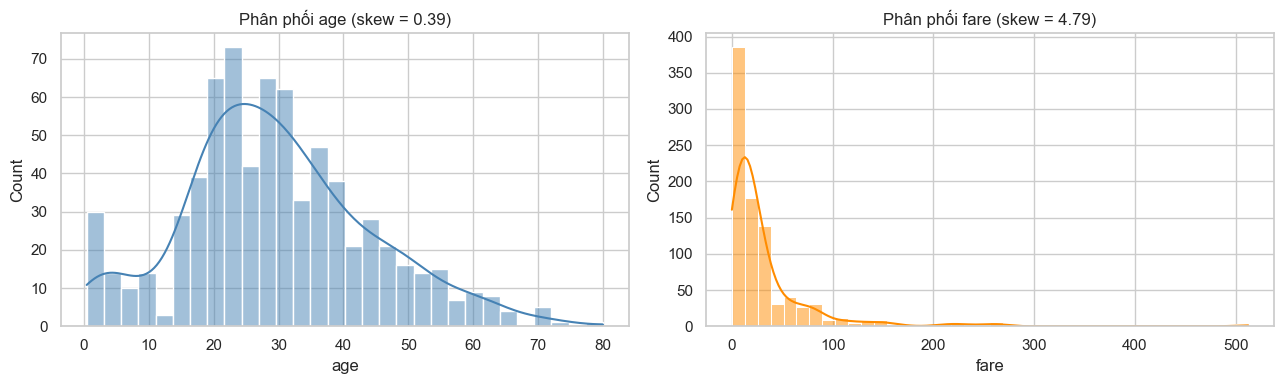

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["age"], kde=True, bins=30, ax=axes[0], color="steelblue")
axes[0].set_title(f"Phân phối age (skew = {df['age'].skew():.2f})")
sns.histplot(df["fare"], kde=True, bins=40, ax=axes[1], color="darkorange")
axes[1].set_title(f"Phân phối fare (skew = {df['fare'].skew():.2f})")
plt.tight_layout()
plt.show()

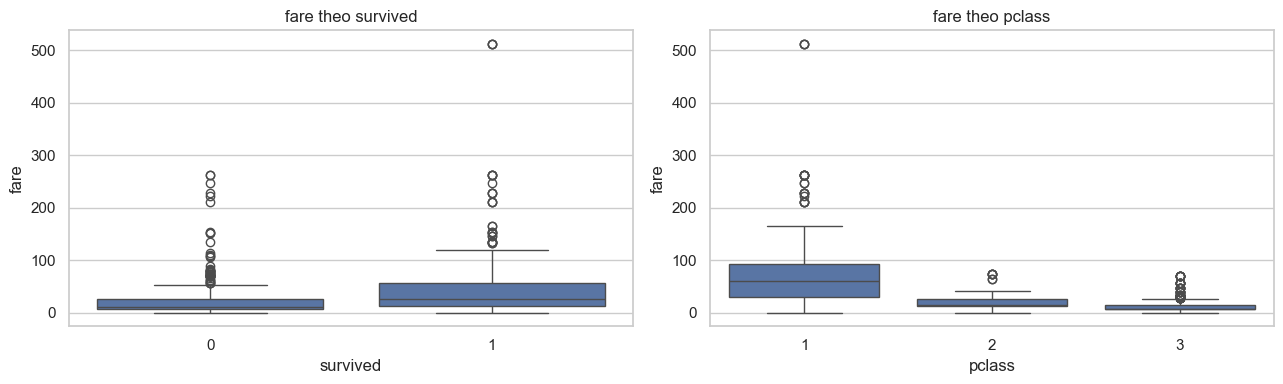

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="survived", y="fare", ax=axes[0])
axes[0].set_title("fare theo survived")
sns.boxplot(data=df, x="pclass", y="fare", ax=axes[1])
axes[1].set_title("fare theo pclass")
plt.tight_layout()
plt.show()

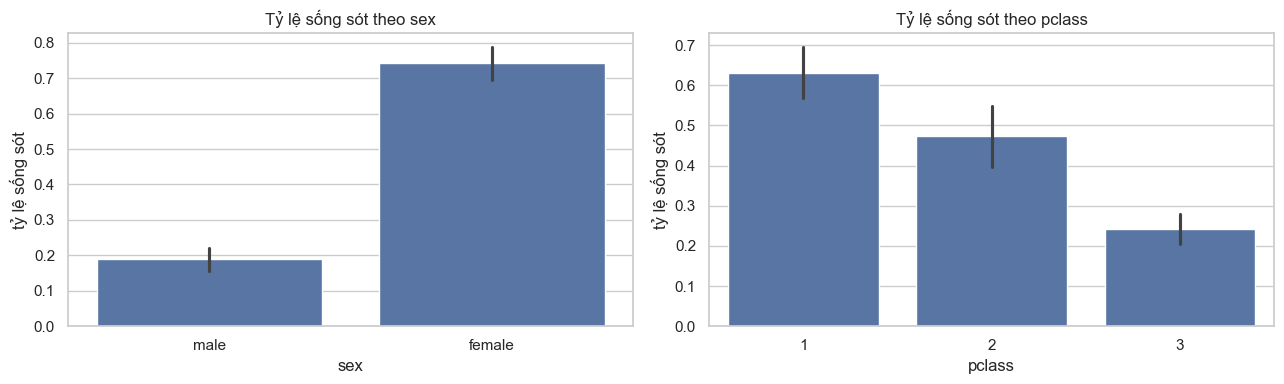

Tỷ lệ sống sót theo sex:
 sex
female    0.742
male      0.189
Name: survived, dtype: float64 

Tỷ lệ sống sót theo pclass:
 pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Tỷ lệ sống sót theo sex")
axes[0].set_ylabel("tỷ lệ sống sót")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1])
axes[1].set_title("Tỷ lệ sống sót theo pclass")
axes[1].set_ylabel("tỷ lệ sống sót")
plt.tight_layout()
plt.show()

# In số liệu cụ thể để nhận xét có căn cứ
print("Tỷ lệ sống sót theo sex:\n", df.groupby("sex")["survived"].mean().round(3), "\n")
print("Tỷ lệ sống sót theo pclass:\n", df.groupby("pclass")["survived"].mean().round(3))

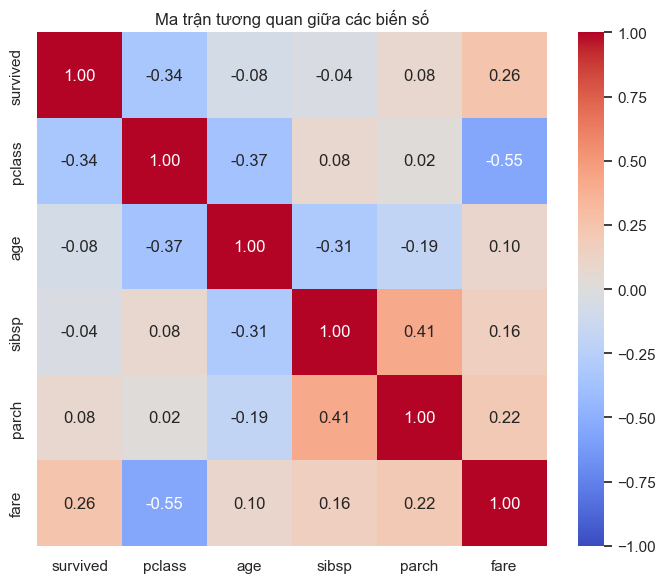

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(7, 6))
corr = df.select_dtypes("number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram:** `age` phân phối gần chuẩn nhưng **lệch phải nhẹ** (skew ≈ 0.39), tập trung nhiều ở nhóm 20–40 tuổi. `fare` **lệch phải rất mạnh** (skew ≈ 4.8): phần lớn hành khách trả giá vé thấp (<50), một số ít trả giá rất cao (>200, cao nhất ~512) tạo ra đuôi dài bên phải → đây là lý do `fare` cần scaler bền vững với outlier.

- **Boxplot:** Trung vị `fare` của nhóm sống sót (`survived=1`) cao hơn rõ rệt nhóm không sống sót; và `fare` giảm dần từ `pclass` 1 → 2 → 3. Có rất nhiều điểm outlier phía trên ở hạng 1, xác nhận đó là các vé đắt tiền có thật của hành khách hạng nhất.

- **Bar survival:** **Giới tính** phân hoá cực mạnh: nữ sống sót ~74% trong khi nam chỉ ~19% (chênh ~55 điểm %) — phản ánh nguyên tắc "phụ nữ và trẻ em trước". Theo **hạng vé**: hạng 1 ~63%, hạng 2 ~47%, hạng 3 chỉ ~24% → hạng vé càng cao càng dễ sống.

- **Heatmap:** Trong nhóm biến số, `pclass` tương quan **âm** mạnh nhất với `survived` (≈ −0.34: hạng số nhỏ = hạng sang = sống nhiều hơn), còn `fare` tương quan **dương** (≈ +0.26). `pclass` và `fare` tương quan âm với nhau (hạng cao thì vé đắt) như kỳ vọng.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

# Lần 1: tách test 15% (giữ nguyên tỷ lệ 2 lớp bằng stratify)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Lần 2: tách val từ phần còn lại. val muốn ~15% tổng => 0.15/0.85 ≈ 0.1765 của phần tmp
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15 / 0.85, random_state=42, stratify=y_tmp
)

n = len(df)
print(f"Train: {X_train.shape}  ({len(X_train)/n:.1%})")
print(f"Val:   {X_val.shape}  ({len(X_val)/n:.1%})")
print(f"Test:  {X_test.shape}  ({len(X_test)/n:.1%})")

print("\nTỷ lệ sống sót (kiểm tra stratify):")
print(f"  Toàn bộ : {y.mean():.3f}")
print(f"  Train   : {y_train.mean():.3f}")
print(f"  Val     : {y_val.mean():.3f}")
print(f"  Test    : {y_test.mean():.3f}")

Train: (623, 7)  (69.9%)
Val:   (134, 7)  (15.0%)
Test:  (134, 7)  (15.0%)

Tỷ lệ sống sót (kiểm tra stratify):
  Toàn bộ : 0.384
  Train   : 0.384
  Val     : 0.388
  Test    : 0.381


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # điền median (bền với outlier)
    ("scaler",  RobustScaler()),                     # RobustScaler vì fare lệch mạnh + nhiều outlier
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # điền mode cho biến phân loại
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),   # one-hot cho sex, embarked
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),   # pclass: giữ nguyên vì đã là số thứ tự 1<2<3
])

# fit CHỈ trên train, rồi transform cho cả 3 tập
preprocess.fit(X_train)
X_train_t = preprocess.transform(X_train)
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)

print("Shape sau biến đổi:")
print("  X_train_t:", X_train_t.shape)
print("  X_val_t  :", X_val_t.shape)
print("  X_test_t :", X_test_t.shape)
print("\nTên cột sau biến đổi:")
print(list(preprocess.get_feature_names_out()))

Shape sau biến đổi:
  X_train_t: (623, 10)
  X_val_t  : (134, 10)
  X_test_t : (134, 10)

Tên cột sau biến đổi:
['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

`fit` là bước **học tham số từ dữ liệu**: `SimpleImputer` học median/mode, `RobustScaler` học median và IQR, `OneHotEncoder` học tập danh mục. Nếu ta `fit` trên **toàn bộ** dữ liệu (gồm cả val/test), thì các thống kê này đã "nhìn thấy" và **hấp thụ thông tin của tập test** — trong khi tập test lẽ ra phải đóng vai trò dữ liệu **hoàn toàn mới, chưa từng thấy** để đánh giá khách quan.

Hậu quả là điểm đánh giá trên val/test bị **thổi phồng một cách ảo** (optimistic bias), không phản ánh đúng năng lực mô hình khi gặp dữ liệu thật ngoài đời. Bằng cách **chỉ `fit` trên `X_train`** rồi `transform` cho val/test bằng đúng tham số đã học, ta mô phỏng đúng tình huống thực tế: tại thời điểm triển khai ta chỉ biết dữ liệu quá khứ (train), còn dữ liệu tương lai (test) là ẩn số. Đó chính là cách chống data leakage.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
counts = df["survived"].value_counts()
props = df["survived"].value_counts(normalize=True)
print("Số lượng mỗi lớp:")
print(counts.rename({0: "0 - không sống", 1: "1 - sống sót"}))
print("\nTỷ lệ mỗi lớp:")
print(props.rename({0: "0 - không sống", 1: "1 - sống sót"}).round(3))

Số lượng mỗi lớp:
survived
0 - không sống    549
1 - sống sót      342
Name: count, dtype: int64

Tỷ lệ mỗi lớp:
survived
0 - không sống    0.616
1 - sống sót      0.384
Name: proportion, dtype: float64


**Trả lời 8:**

1. **Có mất cân bằng nhẹ.** Tỷ lệ hai lớp xấp xỉ **62% không sống sót (0)** và **38% sống sót (1)** — không cân bằng 50/50 nhưng cũng chưa đến mức nghiêm trọng (không phải kiểu 95/5). Đây là mức mất cân bằng vừa phải.

2. **Accuracy có thể đánh lừa** khi dữ liệu mất cân bằng. Ví dụ: một mô hình "lười" luôn dự đoán "không sống sót" cho mọi người sẽ đạt accuracy ~62% mà **không hề học được gì** và bỏ sót hoàn toàn những người sống sót (Recall lớp 1 = 0). Accuracy cao ở đây che giấu việc mô hình vô dụng với lớp thiểu số.

3. Với Titanic, em ưu tiên **F1-score** (kết hợp cân bằng giữa Precision và Recall) làm metric chính, kèm theo xem **Recall** của lớp "sống sót". Lý do: bài toán quan tâm đến việc **nhận diện đúng người sống sót** (lớp thiểu số), và ta không muốn chỉ nhìn Accuracy tổng thể vốn bị lớp đa số chi phối. F1 phản ánh trung thực hơn năng lực mô hình trên lớp thiểu số. (Nếu là bài toán cứu hộ thực tế, ưu tiên Recall để không bỏ sót người cần cứu.)

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. **Đặc trưng tương quan mạnh nhất với sống sót là `sex`**: nữ sống sót ~74% còn nam chỉ ~19% (chênh ~55 điểm %). Trong nhóm biến số, `pclass` tương quan mạnh nhất (r ≈ −0.34, hạng vé càng cao/số càng nhỏ càng dễ sống), tiếp đến là `fare` (r ≈ +0.26).

2. **Cột thiếu nhiều nhất là `deck` (~77%)** nên đã **loại bỏ** vì điền vào sẽ tạo nhiễu. Cột `age` thiếu ~20% được **điền median** (bền với outlier), `embarked` thiếu 2 dòng được **điền mode (`S`)** — tất cả đều fit chỉ trên train.

3. **Biến mục tiêu mất cân bằng nhẹ (~62/38)**. Điều này khiến Accuracy dễ gây hiểu lầm, nên khi đánh giá mô hình cần ưu tiên **F1/Recall** cho lớp "sống sót" thay vì chỉ nhìn Accuracy.

4. **Cần scaling** cho các biến số `age`, `fare`, `sibsp`, `parch` (đặc biệt `fare` lệch mạnh + nhiều outlier → dùng `RobustScaler`); **cần encoding** cho biến danh nghĩa `sex`, `embarked` (one-hot). Riêng `pclass` giữ nguyên vì đã là số có thứ tự.

5. **Điều thú vị/bất ngờ:** `fare` cực kỳ lệch phải (skew ≈ 4.8) với giá vé cao nhất tới ~512 trong khi trung vị chỉ ~14 — chênh lệch giàu nghèo trên tàu rất lớn, và chính khoảng cách giàu-nghèo (thể hiện qua `pclass`/`fare`) lại là yếu tố dự đoán khả năng sống sót mạnh gần ngang với giới tính.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

Tương quan của family_size với survived: 0.017

Tỷ lệ sống sót theo family_size:
              mean  count
family_size              
1            0.304    537
2            0.553    161
3            0.578    102
4            0.724     29
5            0.200     15
6            0.136     22
7            0.333     12
8            0.000      6
11           0.000      7


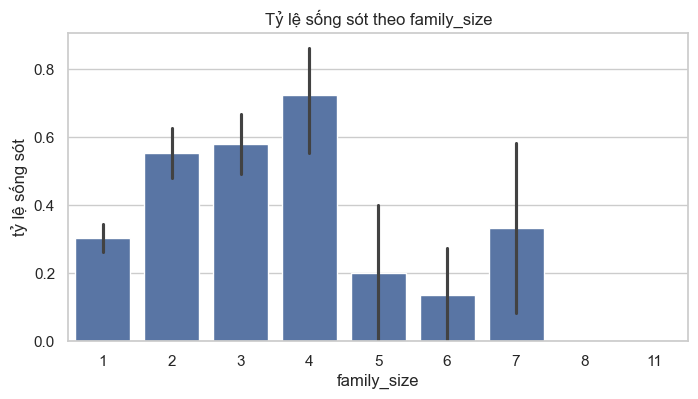

In [14]:
# (tùy chọn) code cho phần Bonus — Feature engineering: family_size
df_bonus = df.copy()
df_bonus["family_size"] = df_bonus["sibsp"] + df_bonus["parch"] + 1

print("Tương quan của family_size với survived:",
      round(df_bonus["family_size"].corr(df_bonus["survived"]), 3))

# Tỷ lệ sống sót theo kích thước gia đình
print("\nTỷ lệ sống sót theo family_size:")
print(df_bonus.groupby("family_size")["survived"].agg(["mean", "count"]).round(3))

plt.figure(figsize=(8, 4))
sns.barplot(data=df_bonus, x="family_size", y="survived")
plt.title("Tỷ lệ sống sót theo family_size")
plt.ylabel("tỷ lệ sống sót")
plt.show()

# Nhận xét: đi một mình (family_size=1) hoặc gia đình quá đông (>4) có tỷ lệ sống thấp,
# trong khi gia đình nhỏ 2-4 người có tỷ lệ sống cao nhất -> quan hệ phi tuyến hình chuông.

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
